In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
data=pd.read_csv("datasets/supermarket_data.csv")

data

,Invoice ID,city,customertype,gender,product,itemprice,quantity,total,date,time,payment,customersalary,rating
0,750-67-8428,Nairobi,Member,Female,Health and beauty,74.69,7,548.9715,1/5/2019,13:08,MPESA,26.1415,9.1
1,226-31-3081,Nakuru,Normal,Female,Electronic accessories,15.28,5,80.2200,3/8/2019,10:29,Cash,3.8200,9.6
2,631-41-3108,Nairobi,Normal,Female,Home and lifestyle,46.33,7,340.5255,3/3/2019,13:23,Credit card,16.2155,7.4
3,123-19-1176,Nairobi,Member,Female,Health and beauty,58.22,8,489.0480,1/27/2019,20:33,MPESA,23.2880,8.4
4,373-73-7910,Nairobi,Normal,Female,Health and beauty,86.31,7,634.3785,2/8/2019,10:37,MPESA,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,233-67-5758,Nakuru,Normal,Male,Health and beauty,40.35,1,42.3675,1/29/2019,13:46,MPESA,2.0175,6.2
997,303-96-2227,Mombasa,Normal,Female,Home and lifestyle,97.38,10,1022.4900,3/2/2019,17:16,MPESA,48.6900,4.4
998,727-02-1313,Nairobi,Member,Male,Food and beverages,31.84,1,33.4320,2/9/2019,13:22,Cash,1.5920,7.7
999,347-56-2442,Nairobi,Normal,Male,Home and lifestyle,65.82,1,69.1110,2/22/2019,15:33,Cash,3.2910,4.1


In [62]:
data.describe()

,itemprice,quantity,total,date,VAT,customerrating
count,1000.00000,1000.000000,1000.000000,1000,1000.000000,1000.00000
mean,55.64901,5.510000,322.966749,2019-02-13 22:58:04.799999744,15.379369,6.97270
min,10.08000,1.000000,10.678500,2019-01-01 00:00:00,0.508500,4.00000
25%,32.87500,3.000000,124.422375,2019-01-25 00:00:00,5.924875,5.50000
50%,55.07000,5.000000,253.848000,2019-02-13 00:00:00,12.088000,7.00000
75%,77.93500,8.000000,471.350250,2019-03-06 00:00:00,22.445250,8.50000
max,99.96000,10.000000,1042.650000,2019-03-30 00:00:00,49.650000,10.00000
std,26.48806,2.923431,245.885335,NaN,11.708825,1.71858


In [54]:
data.shape
data.dtypes
data.head
data.tail
data.info()
data.describe()
data.isnull().sum()
data.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Invoice ID      1001 non-null   object 
 1   city            1001 non-null   object 
 2   customertype    995 non-null    object 
 3   gender          1001 non-null   object 
 4   product         995 non-null    object 
 5   itemprice       998 non-null    float64
 6   quantity        1001 non-null   int64  
 7   total           1001 non-null   float64
 8   date            1001 non-null   object 
 9   time            1001 non-null   object 
 10  payment         1001 non-null   object 
 11  customersalary  1001 non-null   float64
 12  rating          1001 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 101.8+ KB


1

In [55]:
data.drop_duplicates(inplace=True)
data["itemprice"].fillna(data["itemprice"].median(), inplace=True)
data["product"].fillna(data["product"].mode()[0], inplace=True)
data.drop(columns=["Invoice ID"], inplace=True)
data = data.rename(columns={"customersalary": "VAT"})
data = data.rename(columns={"rating": "customerrating"})



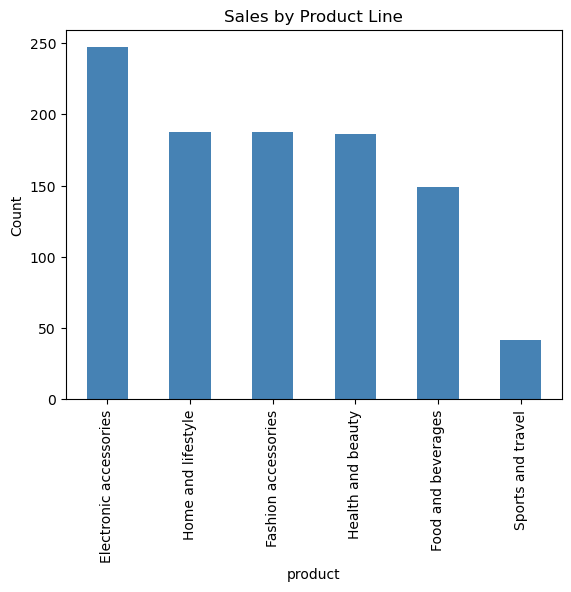

In [56]:
# chart-bestselling product
data["product"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Sales by Product Line")
plt.ylabel("Count")
plt.show()

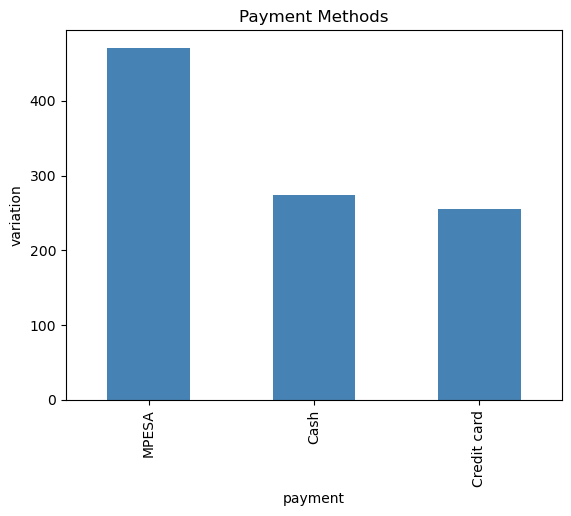

In [ ]:
# payment method
data["payment"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Payment Methods")
plt.ylabel("variation")
plt.show()

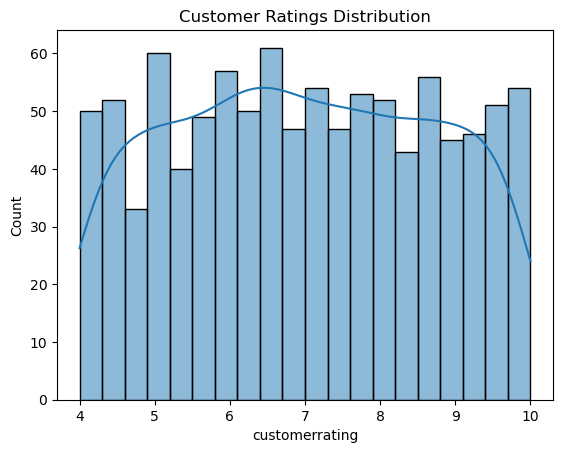

In [ ]:
# rating distribution
sns.histplot(data["customerrating"], bins=20, kde=True)
plt.title("Customer Ratings Distribution")
plt.show()


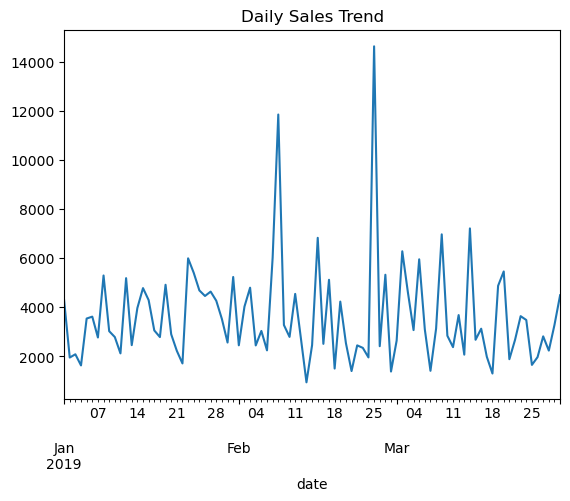

In [60]:
# sales over time
data["date"] = pd.to_datetime(data["date"])
data.groupby("date")["total"].sum().plot()
plt.title("Daily Sales Trend")
plt.show()